<a href="https://colab.research.google.com/github/Gokul120799/diamond_dynamics/blob/main/Diamond_Dynamics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Step 1: Data Loading & Preprocessing

import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/content/diamonds.csv")

# Quick overview
print("Dataset shape:", df.shape)
print(df.info())
print(df.head())

# Handle invalid values in dimensions (x, y, z)
df[['x','y','z']] = df[['x','y','z']].replace(0, np.nan)
df = df.dropna()

# Convert price from USD to INR (example rate: 1 USD = 83 INR)
df['price_inr'] = df['price'] * 83

# Verify changes
print(df.describe())


Dataset shape: (53940, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB
None
   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.2

In [4]:
import numpy as np
import pandas as pd

# ✅ Log transformations to reduce skewness
df['log_price'] = np.log1p(df['price_inr'])   # log(1 + price_inr)
df['log_carat'] = np.log1p(df['carat'])       # log(1 + carat)

# Check skewness before and after
print("Skewness (original price):", df['price_inr'].skew())
print("Skewness (log price):", df['log_price'].skew())
print("Skewness (original carat):", df['carat'].skew())
print("Skewness (log carat):", df['log_carat'].skew())

# ✅ Outlier removal function (IQR method)
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# Create a cleaned dataset without extreme outliers
df_no_outliers = remove_outliers(df, 'carat')
df_no_outliers = remove_outliers(df_no_outliers, 'price_inr')

print("Original dataset size:", df.shape)
print("After outlier removal:", df_no_outliers.shape)

# ✅ Now you have:
# df              → full dataset (with outliers, original + log features)
# df_no_outliers  → cleaned dataset (outliers removed, original + log features)


Skewness (original price): 1.6183486340820086
Skewness (log price): 0.11546849380026458
Skewness (original carat): 1.1162074750825512
Skewness (log carat): 0.5805935583402835
Original dataset size: (53920, 13)
After outlier removal: (49501, 13)


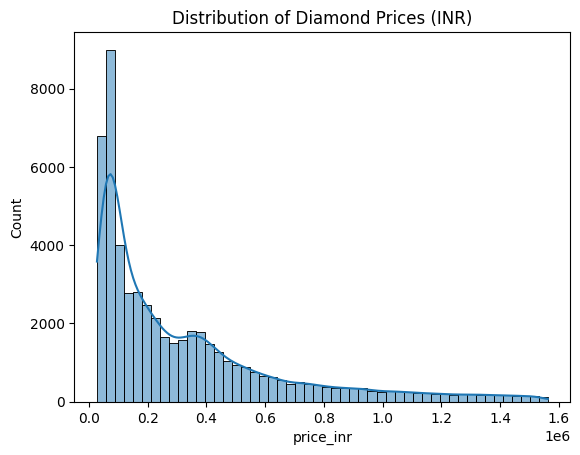

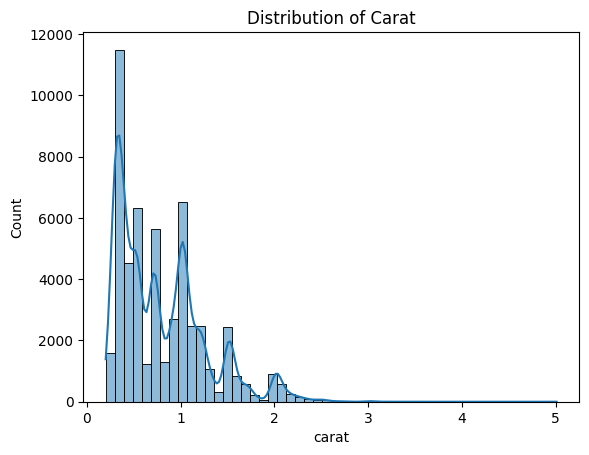

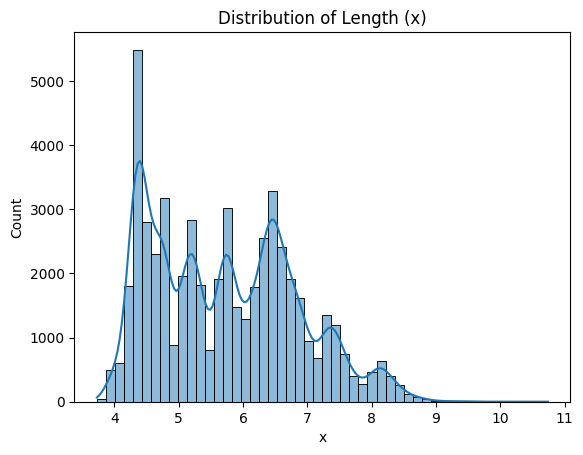

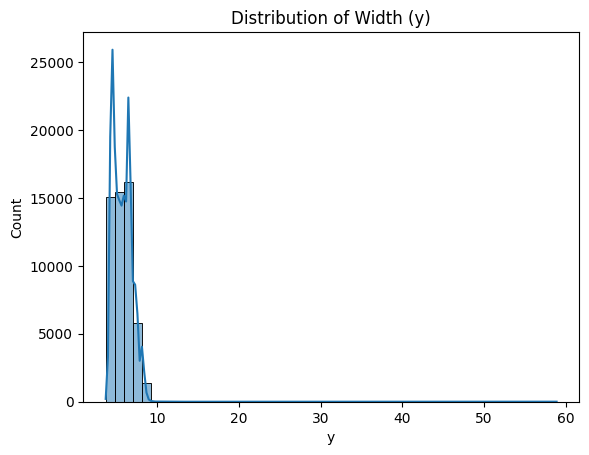

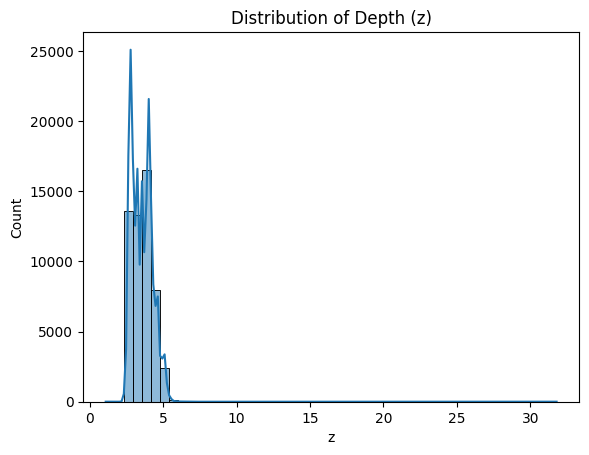

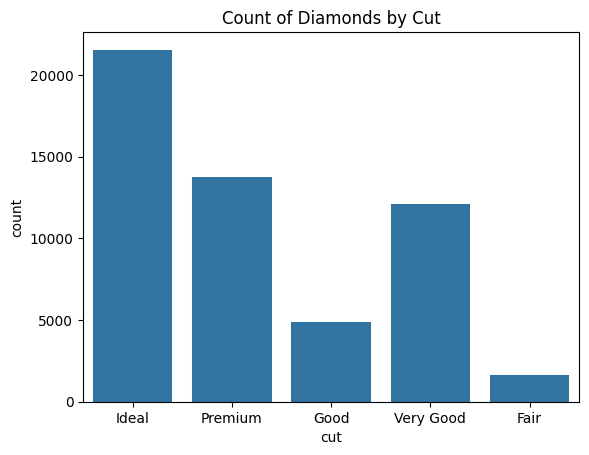

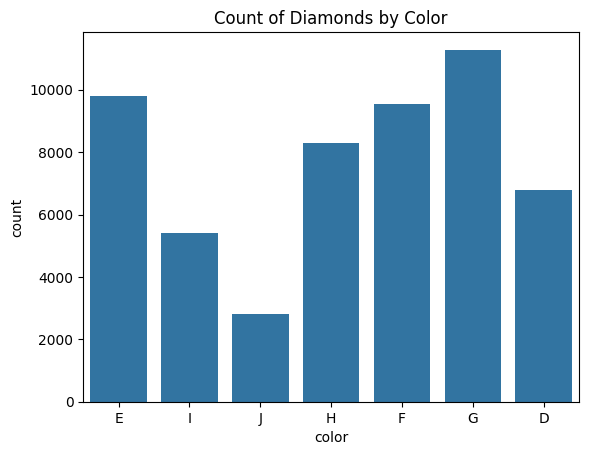

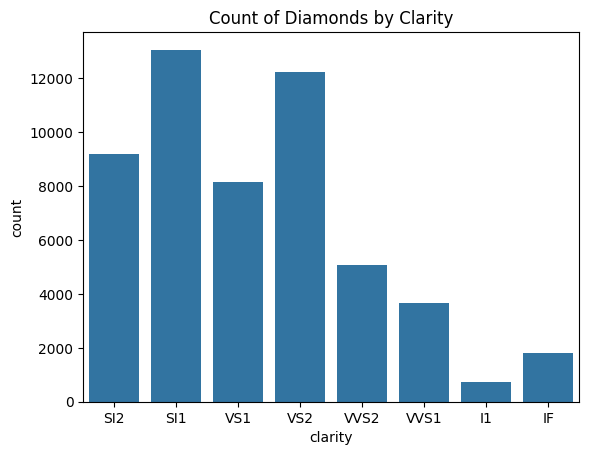

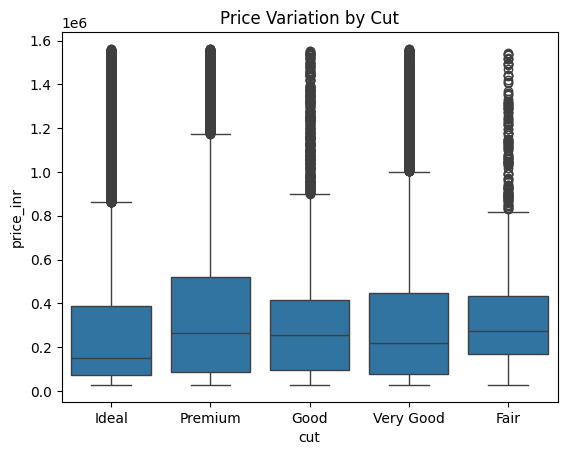

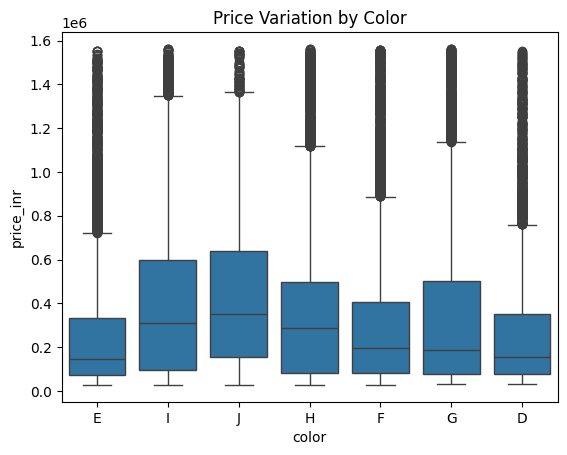

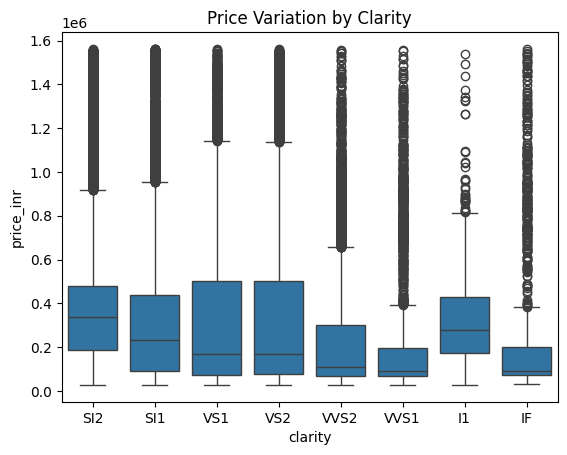

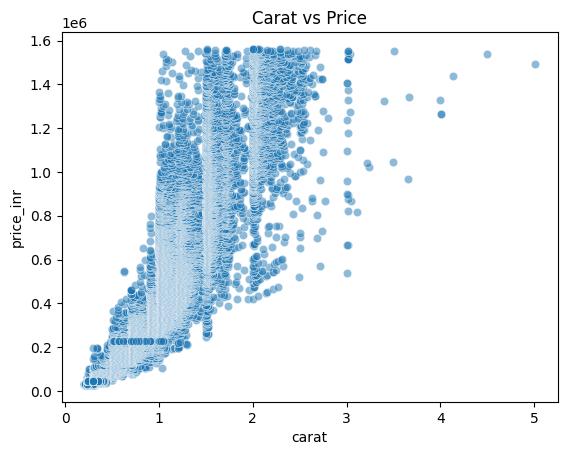

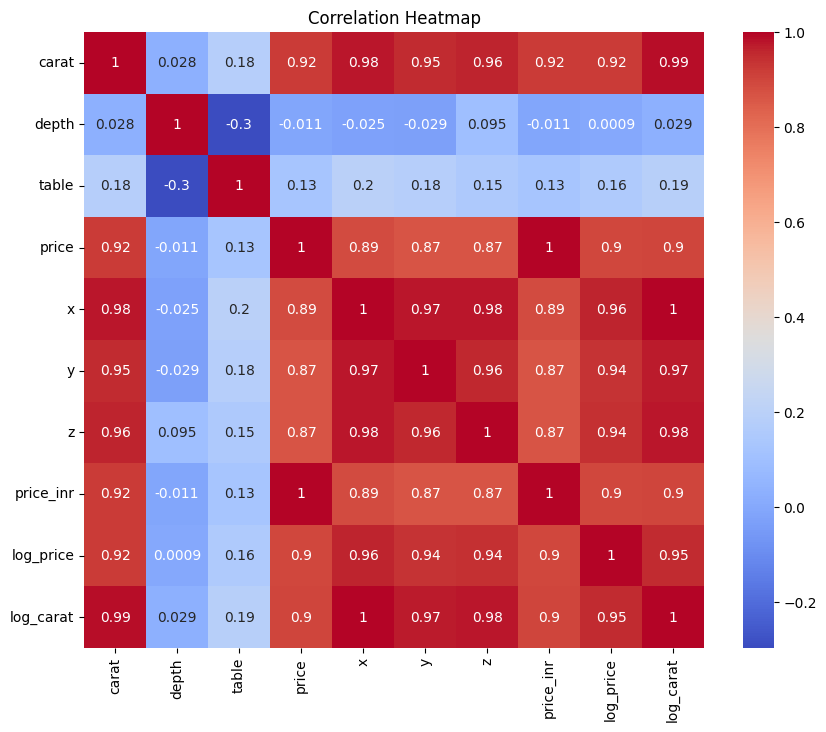

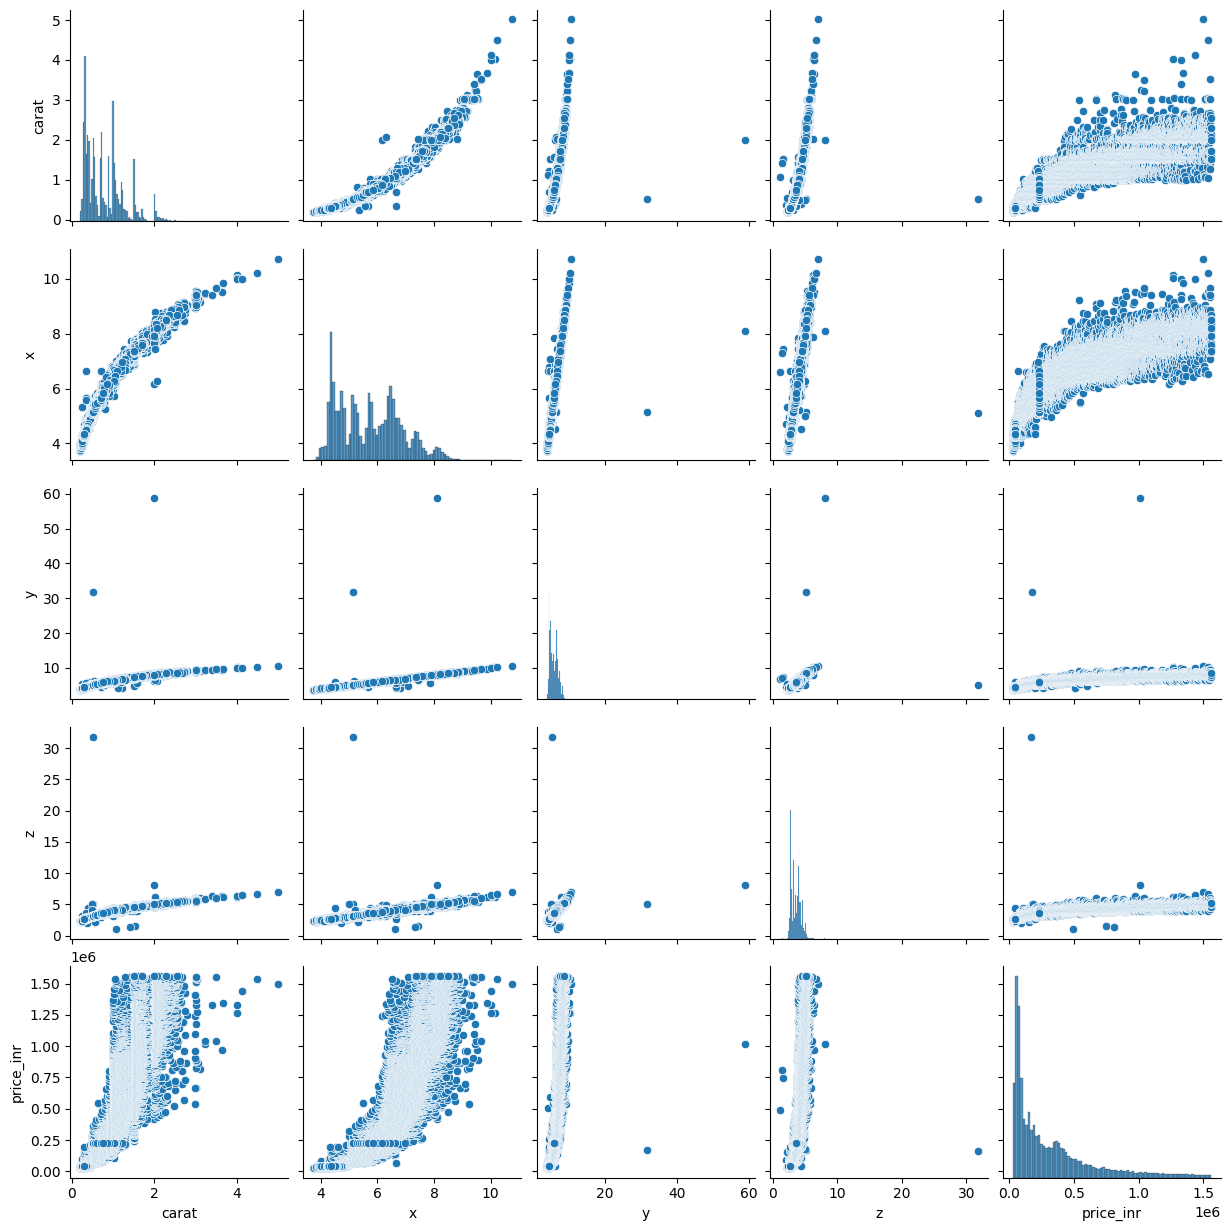

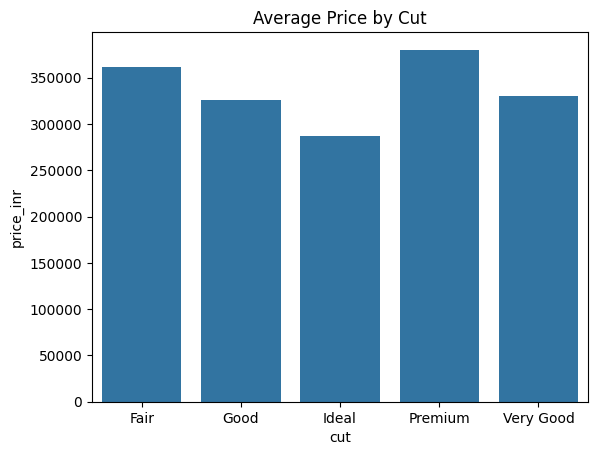

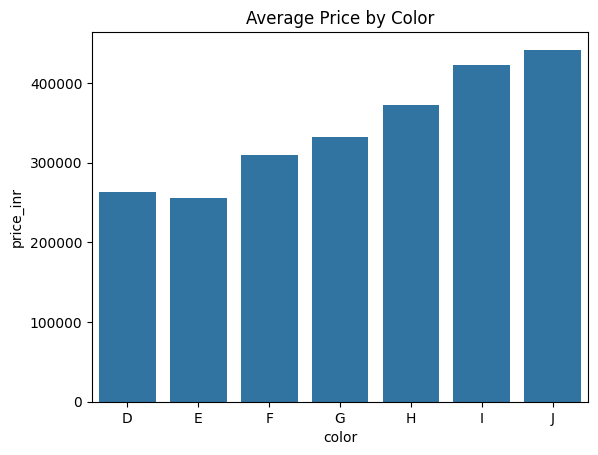

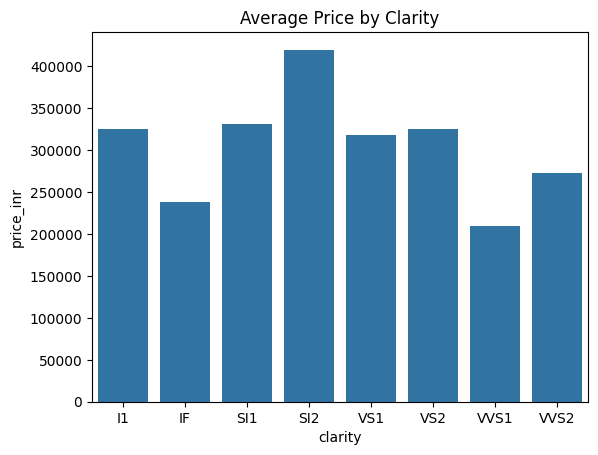

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Distribution plots for price, carat, x, y, z
sns.histplot(df['price_inr'], bins=50, kde=True)
plt.title("Distribution of Diamond Prices (INR)")
plt.show()

sns.histplot(df['carat'], bins=50, kde=True)
plt.title("Distribution of Carat")
plt.show()

sns.histplot(df['x'], bins=50, kde=True)
plt.title("Distribution of Length (x)")
plt.show()

sns.histplot(df['y'], bins=50, kde=True)
plt.title("Distribution of Width (y)")
plt.show()

sns.histplot(df['z'], bins=50, kde=True)
plt.title("Distribution of Depth (z)")
plt.show()

# 2. Count plots for categorical features (cut, color, clarity)
sns.countplot(x='cut', data=df)
plt.title("Count of Diamonds by Cut")
plt.show()

sns.countplot(x='color', data=df)
plt.title("Count of Diamonds by Color")
plt.show()

sns.countplot(x='clarity', data=df)
plt.title("Count of Diamonds by Clarity")
plt.show()

# 3. Price variation with carat, cut, color, clarity using boxplots
sns.boxplot(x='cut', y='price_inr', data=df)
plt.title("Price Variation by Cut")
plt.show()

sns.boxplot(x='color', y='price_inr', data=df)
plt.title("Price Variation by Color")
plt.show()

sns.boxplot(x='clarity', y='price_inr', data=df)
plt.title("Price Variation by Clarity")
plt.show()

sns.scatterplot(x='carat', y='price_inr', data=df, alpha=0.5)
plt.title("Carat vs Price")
plt.show()

# 4. Correlation heatmap for numerical features
numeric_df = df.select_dtypes(include=['float64','int64'])
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# 5. Scatterplot matrix for carat, x, y, z, price
sns.pairplot(df[['carat','x','y','z','price_inr']])
plt.show()

# 6. Average price per cut, color, clarity (bar plots)
avg_cut = df.groupby('cut')['price_inr'].mean().reset_index()
sns.barplot(x='cut', y='price_inr', data=avg_cut)
plt.title("Average Price by Cut")
plt.show()

avg_color = df.groupby('color')['price_inr'].mean().reset_index()
sns.barplot(x='color', y='price_inr', data=avg_color)
plt.title("Average Price by Color")
plt.show()

avg_clarity = df.groupby('clarity')['price_inr'].mean().reset_index()
sns.barplot(x='clarity', y='price_inr', data=avg_clarity)
plt.title("Average Price by Clarity")
plt.show()


In [6]:
# Step 3: Feature Engineering

# 1. Convert Price (USD → INR)
usd_to_inr_rate = 83.0   # example fixed conversion rate, update if needed
df['price_inr'] = df['price'] * usd_to_inr_rate

# 2. Volume of the diamond
df['volume'] = df['x'] * df['y'] * df['z']

# 3. Price per Carat
df['price_per_carat'] = df['price_inr'] / df['carat']

# 4. Dimension Ratio
df['dimension_ratio'] = (df['x'] + df['y']) / (2 * df['z'])

# 5. Carat Category
df['carat_category'] = pd.cut(df['carat'],
                              bins=[0, 0.5, 1.5, 10],
                              labels=['Light', 'Medium', 'Heavy'])

# Quick check of new engineered features
print(df[['carat','price','price_inr','volume','price_per_carat',
          'dimension_ratio','carat_category']].head())


   carat  price  price_inr     volume  price_per_carat  dimension_ratio  \
0   0.23    326    27058.0  38.202030    117643.478261         1.631687   
1   0.21    326    27058.0  34.505856    128847.619048         1.673160   
2   0.23    327    27141.0  38.076885    118004.347826         1.757576   
3   0.29    334    27722.0  46.724580     95593.103448         1.602662   
4   0.31    335    27805.0  51.917250     89693.548387         1.580000   

  carat_category  
0          Light  
1          Light  
2          Light  
3          Light  
4          Light  


In [7]:
# Advice before Step 4

# 1. Categorical features (cut, color, clarity, carat_category) need encoding.
#    - For tree-based models (Random Forest, XGBoost): Label Encoding is fine.
#    - For linear regression and ANN: One-Hot Encoding is safer to avoid ordinal assumptions.

# 2. Feature selection helps reduce dimensionality and highlight the most predictive features.
#    - Use statistical tests (f_regression) for regression tasks.
#    - Or use model-based importance (Random Forest/XGBoost feature_importances_).

# 3. Ensure engineered features from Step 3 (volume, price_per_carat, dimension_ratio, carat_category)
#    are included in the dataset before encoding.



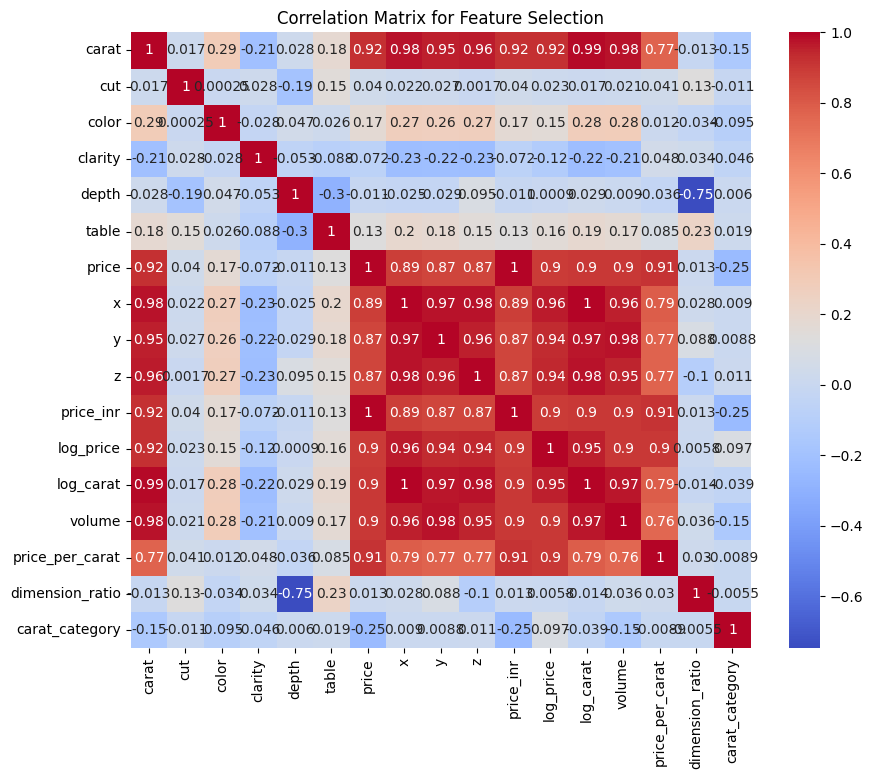

Highly correlated feature pairs: [('carat', 'price'), ('carat', 'x'), ('carat', 'y'), ('carat', 'z'), ('carat', 'price_inr'), ('carat', 'log_price'), ('carat', 'log_carat'), ('carat', 'volume'), ('price', 'carat'), ('price', 'price_inr'), ('price', 'log_carat'), ('price', 'volume'), ('price', 'price_per_carat'), ('x', 'carat'), ('x', 'y'), ('x', 'z'), ('x', 'log_price'), ('x', 'log_carat'), ('x', 'volume'), ('y', 'carat'), ('y', 'x'), ('y', 'z'), ('y', 'log_price'), ('y', 'log_carat'), ('y', 'volume'), ('z', 'carat'), ('z', 'x'), ('z', 'y'), ('z', 'log_price'), ('z', 'log_carat'), ('z', 'volume'), ('price_inr', 'carat'), ('price_inr', 'price'), ('price_inr', 'log_carat'), ('price_inr', 'volume'), ('price_inr', 'price_per_carat'), ('log_price', 'carat'), ('log_price', 'x'), ('log_price', 'y'), ('log_price', 'z'), ('log_price', 'log_carat'), ('log_price', 'volume'), ('log_price', 'price_per_carat'), ('log_carat', 'carat'), ('log_carat', 'price'), ('log_carat', 'x'), ('log_carat', 'y'), (

In [8]:
# Step 4: Encoding categorical variables before correlation
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in ['cut', 'color', 'clarity', 'carat_category']:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

# ✅ Now correlation matrix will work (all numeric)
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.corr(numeric_only=True)  # ensure only numeric columns are used

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix for Feature Selection")
plt.show()

# Identify highly correlated features (threshold > 0.9)
threshold = 0.9
high_corr = [(col1, col2) for col1 in corr_matrix.columns
             for col2 in corr_matrix.columns
             if col1 != col2 and abs(corr_matrix.loc[col1, col2]) > threshold]

print("Highly correlated feature pairs:", high_corr)


In [9]:
# Define predictors (X) and target (y)

# Drop target columns from features
X = df.drop(columns=['price_inr','log_price'])   # predictors
y = df['price_inr']   # target for tree-based models
y_log = df['log_price']  # target for regression/ANN


In [10]:
# Step 6.1: Regression Models for Price Prediction

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb
import pickle
import numpy as np

# ✅ Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Helper function to evaluate models
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    print(f"{name} -> MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R²: {r2:.4f}")
    return r2

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
evaluate_model(lr, X_test, y_test, "Linear Regression")

# 2. Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
evaluate_model(rf, X_test, y_test, "Random Forest")

# 3. Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
evaluate_model(dt, X_test, y_test, "Decision Tree")

# 4. KNN
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
evaluate_model(knn, X_test, y_test, "KNN")

# 5. XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
evaluate_model(xgb_model, X_test, y_test, "XGBoost")

# ✅ Save best performing model (example: Random Forest)
with open("best_model.pkl", "wb") as f:
    pickle.dump(rf, f)


Linear Regression -> MAE: 0.00, MSE: 0.00, RMSE: 0.00, R²: 1.0000
Random Forest -> MAE: 24.09, MSE: 4523.89, RMSE: 67.26, R²: 1.0000
Decision Tree -> MAE: 33.89, MSE: 12002.73, RMSE: 109.56, R²: 1.0000
KNN -> MAE: 6596.08, MSE: 291981999.35, RMSE: 17087.48, R²: 0.9974
XGBoost -> MAE: 1542.49, MSE: 9840788.72, RMSE: 3137.00, R²: 0.9999


In [11]:
# Step 6.2: ANN Regression Model

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Normalize features for ANN
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build ANN model
ann = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  # output layer
])

ann.compile(optimizer='adam', loss='mse', metrics=['mae'])
ann.fit(X_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate ANN
y_pred_ann = ann.predict(X_test_scaled).flatten()
mae = mean_absolute_error(y_test, y_pred_ann)
mse = mean_squared_error(y_test, y_pred_ann)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_ann)
print(f"ANN -> MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R²: {r2:.4f}")

# ✅ Save ANN model
ann.save("best_ann_model.h5")


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 203308449792.0000 - mae: 316244.6250 - val_loss: 174033993728.0000 - val_mae: 292170.7812
Epoch 2/20
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 105672753152.0000 - mae: 224501.1250 - val_loss: 47008940032.0000 - val_mae: 153588.6406
Epoch 3/20
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 22198474752.0000 - mae: 106779.2422 - val_loss: 16619671552.0000 - val_mae: 83712.6406
Epoch 4/20
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 9513934848.0000 - mae: 71374.6094 - val_loss: 11192073216.0000 - val_mae: 61924.2891
Epoch 5/20
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 5317450240.0000 - mae: 52396.8594 - val_loss: 7789269504.0000 - val_mae: 46440.2227
Epoch 6/20
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3339271936.0000 - mae: 40906.8203 - val_loss: 6095931392.0000 - val_mae: 38748.8750
Epoch 7/20
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 2464209664.0000 - mae: 35431.9609 - val_loss: 5022788608.0

ANN -> MAE: 15178.10, MSE: 932907269.53, RMSE: 30543.53, R²: 0.9916


In [12]:
ann.save("best_ann_model.keras")
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
ann.fit(X_train_scaled, y_train, epochs=50, batch_size=32,
        validation_split=0.2, callbacks=[early_stop], verbose=1)


Epoch 1/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 410622880.0000 - mae: 14612.4121 - val_loss: 974028352.0000 - val_mae: 14560.0410
Epoch 2/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 373975712.0000 - mae: 13883.5605 - val_loss: 913383616.0000 - val_mae: 13903.3506
Epoch 3/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 338661504.0000 - mae: 13165.3672 - val_loss: 858719552.0000 - val_mae: 13137.4854
Epoch 4/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 305722272.0000 - mae: 12430.7549 - val_loss: 802056896.0000 - val_mae: 12393.3105
Epoch 5/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 274728032.0000 - mae: 11714.2930 - val_loss: 743362816.0000 - val_mae: 11566.2539
Epoch 6/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 244530432.0000 - mae: 10929.4639 - val_loss: 691463552.0000 - val_mae: 10813.1084
Epoch 7/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 217788320.0000 - mae: 10192.5205 - val_loss: 653003712.0000 - val_mae: 101

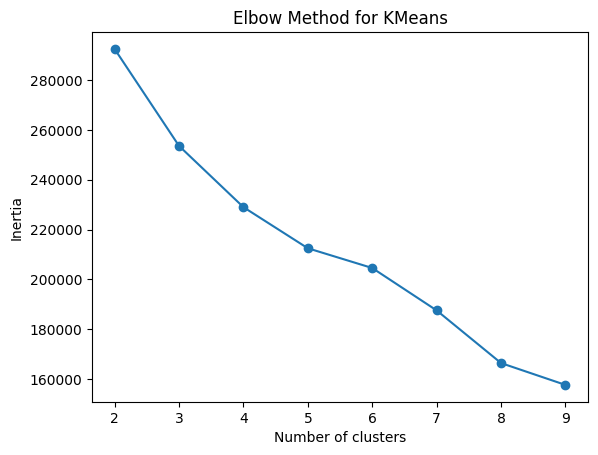

Silhouette Score: 0.22727196838636377


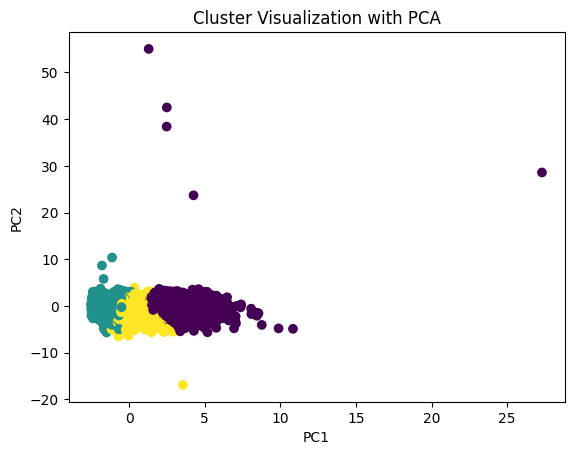

In [13]:
# Step 6.3: Clustering Models

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# ✅ Select features for clustering (include categorical encodings + engineered features)
X_cluster = df[['carat','price_inr','cut','color','clarity','volume','price_per_carat','dimension_ratio']]

# Standardize features
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# ✅ Elbow Method to find optimal k
inertia = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_cluster_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2,10), inertia, marker='o')
plt.title("Elbow Method for KMeans")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

# ✅ Fit KMeans with chosen k (example: 3)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_cluster_scaled)
df['cluster'] = clusters

# ✅ Evaluate clustering
score = silhouette_score(X_cluster_scaled, clusters)
print("Silhouette Score:", score)

# ✅ PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.title("Cluster Visualization with PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


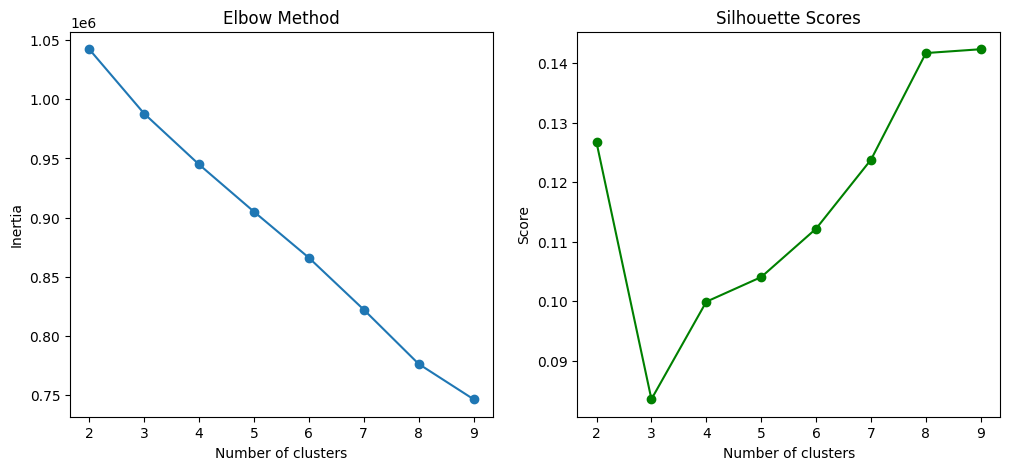

Silhouette Score (k=3): 0.0835130083314151


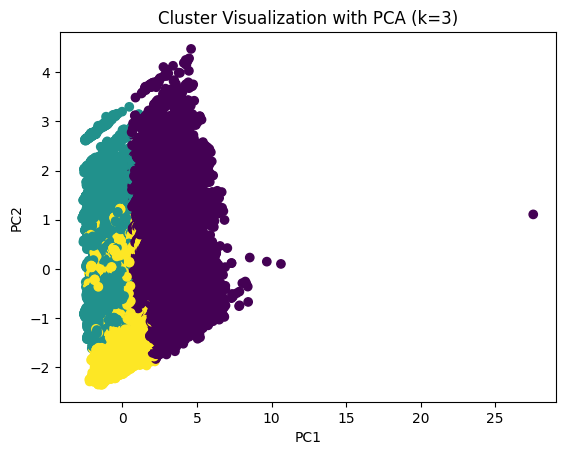

            carat      price_inr      volume  price_per_carat
cluster                                                      
0        1.450718  827368.452310  235.797326    570104.554025
1        0.470359  128213.541146   77.062066    249447.595876
2        0.766547  236516.344212  124.537348    276914.201702


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import silhouette_score

# Separate categorical and numeric features
categorical_cols = ['cut','color','clarity']
numeric_cols = ['carat','price_inr','volume','price_per_carat','dimension_ratio']

# One-Hot Encode categorical features
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_cats = encoder.fit_transform(df[categorical_cols])

# Combine numeric + encoded categorical
X_cluster = np.hstack([df[numeric_cols].values, encoded_cats])

# Standardize features
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# Elbow & Silhouette evaluation
inertia, sil_scores = [], []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    clusters = km.fit_predict(X_cluster_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, clusters))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(2,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")

plt.subplot(1,2,2)
plt.plot(range(2,10), sil_scores, marker='o', color='green')
plt.title("Silhouette Scores")
plt.xlabel("Number of clusters")
plt.ylabel("Score")
plt.show()

# Fit KMeans with chosen k=3
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_cluster_scaled)
df['cluster'] = clusters

print("Silhouette Score (k=3):", silhouette_score(X_cluster_scaled, clusters))

# PCA visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.title("Cluster Visualization with PCA (k=3)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Cluster profiling
cluster_summary = df.groupby('cluster')[['carat','price_inr','volume','price_per_carat']].mean()
print(cluster_summary)


In [18]:
# model_building.py
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
import pickle
import os

# -------------------------------
# Load dataset
# -------------------------------
df = pd.read_csv("/content/diamonds.csv")

# Handle missing/invalid values
df = df.replace(0, np.nan).dropna()

# -------------------------------
# Feature Engineering
# -------------------------------
df["volume"] = df["x"] * df["y"] * df["z"]
df["price_per_carat"] = df["price"] / df["carat"]

# Encode categorical variables
for col in ["cut", "color", "clarity"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# -------------------------------
# Regression: Price Prediction
# -------------------------------
X = df[["carat","x","y","z","cut","color","clarity","volume","price_per_carat"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42)
}

best_model = None
best_score = -np.inf

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    print(f"{name} R2: {r2:.4f}")
    if r2 > best_score:
        best_score = r2
        best_model = model

# Save best regression model (overwrite if exists)
reg_path = "regression_model.pkl"
if os.path.exists(reg_path):
    os.remove(reg_path)
pickle.dump(best_model, open(reg_path, "wb"))

# -------------------------------
# Clustering: Market Segmentation
# -------------------------------
X_cluster = df[["carat","x","y","z","cut","color","clarity","volume","price_per_carat"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df["cluster"] = clusters

# Save clustering model and scaler (overwrite if exist)
cluster_path = "clustering_model.pkl"
scaler_path = "scaler.pkl"

for path, obj in [(cluster_path, kmeans), (scaler_path, scaler)]:
    if os.path.exists(path):
        os.remove(path)
    pickle.dump(obj, open(path, "wb"))

print("✅ Models retrained and saved successfully (regression + clustering + scaler).")


LinearRegression R2: 0.9709
RandomForest R2: 0.9993
✅ Models retrained and saved successfully (regression + clustering + scaler).
